In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_excel('../dataset/raw_data/crime_data_2001_2014.xlsx')


In [3]:
df.head()

,STATE/UT,DISTRICT,YEAR,MURDER,RAPE,KIDNAPPING & ABDUCTION,THEFT,DOWRY DEATHS,OTHER CRIMES,TOTAL IPC CRIMES
0,ANDHRA PRADESH,ADILABAD,2001,161,50,46,438,16,3443,4154
1,ANDHRA PRADESH,ANANTAPUR,2001,276,23,53,573,7,3193,4125
2,ANDHRA PRADESH,CHITTOOR,2001,158,27,59,974,14,4586,5818
3,ANDHRA PRADESH,CUDDAPAH,2001,133,20,25,275,17,2670,3140
4,ANDHRA PRADESH,EAST GODAVARI,2001,149,23,49,1483,12,4791,6507


In [4]:
#Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10602
Columns: 10


In [5]:
#Column names
df.columns

Index(['STATE/UT', 'DISTRICT', 'YEAR', 'MURDER', 'RAPE',
       'KIDNAPPING & ABDUCTION', 'THEFT', 'DOWRY DEATHS', 'OTHER CRIMES',
       'TOTAL IPC CRIMES'],
      dtype='object')

In [6]:
#Rename Columns
df = df.rename(columns={
    'STATE/UT':'STATE',
    'KIDNAPPING & ABDUCTION':'KIDNAPPING',
    'DOWRY DEATHS':'DOWRY_DEATHS',
    'OTHER CRIMES':'OTHER_CRIMES',
    'TOTAL IPC CRIMES':'TOTAL_CRIMES'
})

df.columns

Index(['STATE', 'DISTRICT', 'YEAR', 'MURDER', 'RAPE', 'KIDNAPPING', 'THEFT',
       'DOWRY_DEATHS', 'OTHER_CRIMES', 'TOTAL_CRIMES'],
      dtype='object')

In [7]:
#Data Types & Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10602 entries, 0 to 10601
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   STATE         10602 non-null  object
 1   DISTRICT      10602 non-null  object
 2   YEAR          10602 non-null  int64 
 3   MURDER        10602 non-null  int64 
 4   RAPE          10602 non-null  int64 
 5   KIDNAPPING    10602 non-null  int64 
 6   THEFT         10602 non-null  int64 
 7   DOWRY_DEATHS  10602 non-null  int64 
 8   OTHER_CRIMES  10602 non-null  int64 
 9   TOTAL_CRIMES  10602 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 828.4+ KB


In [8]:
#Statistical Summary
df.describe()

,YEAR,MURDER,RAPE,KIDNAPPING,THEFT,DOWRY_DEATHS,OTHER_CRIMES,TOTAL_CRIMES
count,10602.000000,10602.000000,10602.000000,10602.000000,10602.000000,10602.000000,10602.000000,10602.000000
mean,2007.657517,161.862856,55.321920,86.550745,1067.122618,19.467365,3876.507168,5266.832673
std,4.029622,601.696902,194.771882,340.305050,3956.155552,93.918664,13714.312319,18248.030109
min,2001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2004.000000,33.000000,8.000000,10.000000,148.000000,1.000000,581.000000,861.000000
50%,2008.000000,68.000000,22.000000,28.000000,339.000000,5.000000,1517.000000,2155.000000
75%,2011.000000,123.000000,45.000000,64.000000,693.000000,16.000000,3071.500000,4069.000000
max,2014.000000,15565.000000,4335.000000,11183.000000,80744.000000,2335.000000,176632.000000,234385.000000


In [9]:
#Check Missing Values
df.isnull().sum()

STATE           0
DISTRICT        0
YEAR            0
MURDER          0
RAPE            0
KIDNAPPING      0
THEFT           0
DOWRY_DEATHS    0
OTHER_CRIMES    0
TOTAL_CRIMES    0
dtype: int64

In [10]:
#Check Duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
#Unique Values
print("States:", df['STATE'].nunique())
print("Districts:", df['DISTRICT'].nunique())
print("Years:", df['YEAR'].unique())

States: 35
Districts: 939
Years: [2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014]


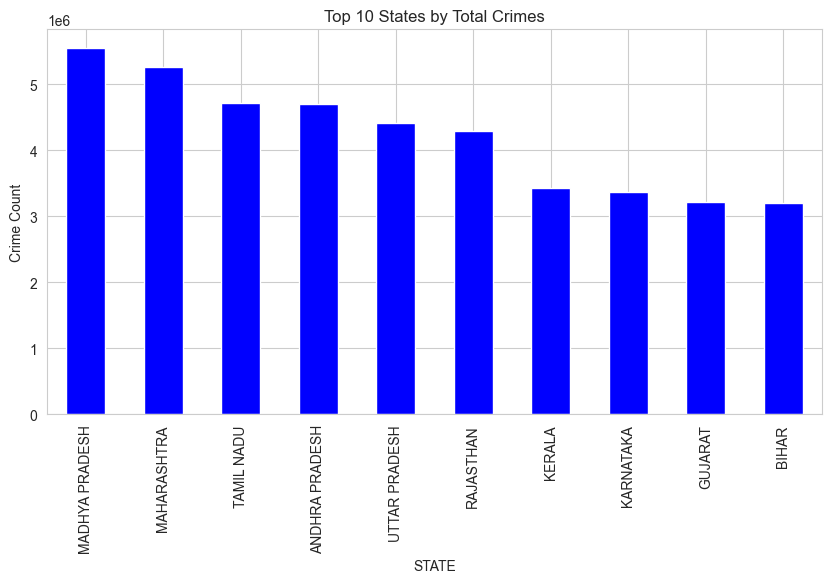

In [12]:
#Top 10 States by Crime
top_states = df.groupby('STATE')['TOTAL_CRIMES'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar', color='blue')
plt.title("Top 10 States by Total Crimes")
plt.ylabel("Crime Count")
plt.savefig('../outputs/graphs/top_states.png', bbox_inches='tight',dpi=100)
plt.show()